# Laboratorio 7 — Spark MLlib
**CC3066 — Data Science | UVG | Semestre II - 2026**

Integrantes: Jose Ordoñez, Adrian Gonzales, Alejandro Antón

1. Carga, armonización y calidad de datos
2. Estadística descriptiva y preguntas de exploración

> **Nota:** este notebook asume que los cinco archivos originales de la ENEIC (Personas, I–IV de 2025 y I de 2026) ya están descargados localmente. Ajuste la variable `DATA_DIR` y los nombres de archivo en la celda de configuración antes de ejecutar.

## 0. Configuración del entorno

In [1]:
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] = os.environ["HADOOP_HOME"] + "\\bin;" + os.environ["PATH"]

spark = (
    SparkSession.builder
    .appName("Lab7_SparkMLlib_ENEIC")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [2]:
# --- Rutas de los archivos originales (la carpeta data/ contiene los descargados) ---
DATA_DIR = "./data"
OUT_DIR = "./output"
os.makedirs(OUT_DIR, exist_ok=True)

# Cada entrada: periodo_archivo -> (candidatos de nombre de archivo, anio_archivo, trimestre_calendario).
# El trimestre_calendario se asigna por PROCEDENCIA DEL ARCHIVO, no por la columna TRIMESTRE.
# Se usan el/los primer(os) nombre(s) que existan dentro de data/: asi se toleran variantes de nombre del INE.
ARCHIVOS = {
    "2025T1": {"candidatos": ["Personas_ENEIC_T1_2025.xlsx", "Base-de-datos-Personas-ENEIC-I-2025.xlsx", "Personas ENEIC I 2025.xlsx"], "anio": 2025, "trimcal": 1},
    "2025T2": {"candidatos": ["Personas-ENEIC-T2-2025.xlsx", "Base-de-datos-Personas-ENEIC-II-2025.xlsx", "Personas ENEIC II 2025.xlsx"], "anio": 2025, "trimcal": 2},
    "2025T3": {"candidatos": ["Personas-ENEIC-T3-2025.xlsx", "Base-de-datos-Personas-ENEIC-III-2025.xlsx", "Personas ENEIC III 2025.xlsx"], "anio": 2025, "trimcal": 3},
    "2025T4": {"candidatos": ["Personas-ENEIC-T4-2025.xlsx", "Base-de-datos-Personas-ENEIC-IV-2025.xlsx", "Personas ENEIC IV 2025.xlsx"], "anio": 2025, "trimcal": 4},
    "2026T1": {"candidatos": ["Base-de-datos-Personas-ENEIC-I-2026.xlsx", "Personas_ENEIC_T1_2026.xlsx", "Personas ENEIC I 2026.xlsx"], "anio": 2026, "trimcal": 1},
}

# Solo se procesan los archivos que efectivamente existen en data/
ARCHIVOS_DISPONIBLES = {}
for periodo, meta in ARCHIVOS.items():
    for cand in meta["candidatos"]:
        p = os.path.join(DATA_DIR, cand)
        if os.path.exists(p):
            ARCHIVOS_DISPONIBLES[periodo] = {"path": p, "anio": meta["anio"], "trimcal": meta["trimcal"]}
            break

faltantes = sorted(set(ARCHIVOS) - set(ARCHIVOS_DISPONIBLES))
if faltantes:
    print("AVISO: no encontrados en data/ (se omiten por ahora):", faltantes)
    print("      Descargalos del INE y colocarlos en data/ para que se incluyan automaticamente.")

# Formato final usado por el resto del notebook: periodo -> (path, anio, trimcal)
ARCHIVOS = ARCHIVOS_DISPONIBLES


# Columnas originales que necesitamos de cada archivo (ver tabla "Variables que utilizara")
COLS_ORIGINALES = [
    "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE",
    "DOMINIO", "OCUPADOS",
    "P02A03",              # edad
    "P05C07A", "P05C07B",  # antiguedad (anios, meses)
    "P05H01A",             # horas semanales
    "P03A03A",             # nivel educativo
    "P05C16",              # categoria ocupacional
    "P05D01",              # salario mensual (objetivo)
]


AVISO: no encontrados en data/ (se omiten por ahora): ['2025T3', '2025T4']
      Descargalos del INE y colocarlos en data/ para que se incluyan automaticamente.


## 1. Carga, armonización y calidad de datos (5 pts)

Se lee cada archivo Excel con pandas, se seleccionan únicamente las columnas requeridas,
se homologan los tipos (un mismo código puede llegar como número o como texto) y se agregan
las columnas de identificación del período (`periodo_archivo`, `anio_archivo`,
`trimestre_calendario`, `archivo_origen`). Luego se convierte cada archivo a un DataFrame
de Spark con esquema explícito.

In [3]:
def leer_y_normalizar(periodo_archivo, meta):
    """Lee un archivo de Personas con pandas, selecciona columnas, homologa tipos
    y agrega columnas de identificación del período de procedencia."""
    df = pd.read_excel(meta["path"], engine="openpyxl")

    # Homologar nombres de columnas (por si llegan en minúsculas / con espacios)
    df.columns = [str(c).strip().upper() for c in df.columns]

    faltantes = [c for c in COLS_ORIGINALES if c not in df.columns]
    if faltantes:
        raise ValueError(f"[{periodo_archivo}] Faltan columnas esperadas: {faltantes}")

    df = df[COLS_ORIGINALES].copy()

    # --- Homologar tipos: un mismo código puede llegar como numero o como texto ---
    # Nota: se construye una lista con None real para los faltantes; con pandas StrDtype
    # un .apply() puede reintroducir el NaN como cadena "NaN" en vez de un verdadero null.
    def _homologar_codigo(v):
        if pd.isna(v) or str(v).strip() == "":
            return None
        sv = str(v).strip()
        if sv.replace(".0", "").replace(".", "").lstrip("-").isdigit():
            return str(int(float(sv)))
        return sv

    codigos_categoricos = ["DOMINIO", "P03A03A", "P05C16"]
    # Se construyen columnas con dtype object (None real) y se reemplazan las originales:
    # asignar una lista directamente en pandas 3.0 vuelve a convertir None en NaN.
    cat_cols = pd.DataFrame(
        {c: pd.Series([_homologar_codigo(v) for v in df[c].tolist()], dtype="object")
         for c in codigos_categoricos},
        index=df.index,
    )
    df = df.drop(columns=codigos_categoricos).join(cat_cols)

    # Columnas numericas -> float64 (Spark exige float64 para DoubleType, no int)
    cols_numericas = ["NUM_HOGAR", "NUM_PERSONA", "ANIO", "TRIMESTRE", "OCUPADOS",
                      "P02A03", "P05C07A", "P05C07B", "P05H01A", "P05D01", "FACTOR"]
    for c in cols_numericas:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("float64")

    # --- Columnas de identificacion del periodo (a partir del ARCHIVO, no de TRIMESTRE) ---
    df["periodo_archivo"] = periodo_archivo
    df["anio_archivo"] = meta["anio"]
    df["trimestre_calendario"] = meta["trimcal"]
    df["archivo_origen"] = os.path.basename(meta["path"])

    # Reordenar columnas segun el esquema: createDataFrame(pdf, schema=...) alinea por POSICION
    df = df[[f.name for f in esquema.fields]]

    return df

esquema = T.StructType([
    T.StructField("NUM_HOGAR", T.DoubleType(), True),
    T.StructField("NUM_PERSONA", T.DoubleType(), True),
    T.StructField("FACTOR", T.DoubleType(), True),
    T.StructField("ANIO", T.DoubleType(), True),
    T.StructField("TRIMESTRE", T.DoubleType(), True),
    T.StructField("DOMINIO", T.StringType(), True),
    T.StructField("OCUPADOS", T.DoubleType(), True),
    T.StructField("P02A03", T.DoubleType(), True),
    T.StructField("P05C07A", T.DoubleType(), True),
    T.StructField("P05C07B", T.DoubleType(), True),
    T.StructField("P05H01A", T.DoubleType(), True),
    T.StructField("P03A03A", T.StringType(), True),
    T.StructField("P05C16", T.StringType(), True),
    T.StructField("P05D01", T.DoubleType(), True),
    T.StructField("periodo_archivo", T.StringType(), True),
    T.StructField("anio_archivo", T.IntegerType(), True),
    T.StructField("trimestre_calendario", T.IntegerType(), True),
    T.StructField("archivo_origen", T.StringType(), True),
])

conteo_original = {}
spark_dfs = {}

for periodo, meta in ARCHIVOS.items():
    pdf = leer_y_normalizar(periodo, meta)
    conteo_original[periodo] = len(pdf)
    sdf = spark.createDataFrame(pdf, schema=esquema)
    spark_dfs[periodo] = sdf.persist()

pd.Series(conteo_original, name="registros_originales").to_frame()


,registros_originales
2025T1,51588
2025T2,51167
2026T1,49843


In [4]:
# --- Unir los archivos de 2025 disponibles mediante unionByName ----------------------
periodos_2025 = [p for p in ["2025T1", "2025T2", "2025T3", "2025T4"] if p in spark_dfs]
print("Periodos de 2025 unidos:", periodos_2025)

df_2025_raw = spark_dfs[periodos_2025[0]]
for p in periodos_2025[1:]:
    df_2025_raw = df_2025_raw.unionByName(spark_dfs[p])

df_2026_raw = spark_dfs["2026T1"]

print("Registros 2025 (antes de filtros):", df_2025_raw.count())
print("Registros 2026 (antes de filtros):", df_2026_raw.count())

print("\nEsquema df_2025_raw:")
df_2025_raw.printSchema()
df_2025_raw.select(
    "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "P02A03", "P05C16",
    "P05D01", "DOMINIO", "P03A03A"
).show(5, truncate=False)


Periodos de 2025 unidos: ['2025T1', '2025T2']
Registros 2025 (antes de filtros): 102755
Registros 2026 (antes de filtros): 49843

Esquema df_2025_raw:
root
 |-- NUM_HOGAR: double (nullable = true)
 |-- NUM_PERSONA: double (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: double (nullable = true)
 |-- TRIMESTRE: double (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- OCUPADOS: double (nullable = true)
 |-- P02A03: double (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- P05D01: double (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)

+---------------+---------+-----------+------+------+------+-------+-------+
|periodo_archivo|NUM_HOGAR|

In [5]:
# --- Cantidad y porcentaje de faltantes por variable seleccionada, ANTES de filtrar ---
def tabla_faltantes(df, nombre):
    total = df.count()
    filas = []
    tipos = {f.name: f.dataType for f in df.schema.fields}
    for c in COLS_ORIGINALES:
        cond = F.col(c).isNull()
        if isinstance(tipos[c], T.DoubleType):
            cond = cond | F.isnan(F.col(c))
        nulos = df.filter(cond).count()
        filas.append((c, nulos, round(100 * nulos / total, 2) if total else None))
    out = pd.DataFrame(filas, columns=["variable", "faltantes", "pct_faltantes"])
    out.insert(0, "conjunto", nombre)
    return out

faltantes_2025 = tabla_faltantes(df_2025_raw, "2025 (train/val)")
faltantes_2026 = tabla_faltantes(df_2026_raw, "2026 (test)")
pd.concat([faltantes_2025, faltantes_2026], ignore_index=True)


,conjunto,variable,faltantes,pct_faltantes
0,2025 (train/val),NUM_HOGAR,0,0.00
1,2025 (train/val),NUM_PERSONA,0,0.00
2,2025 (train/val),FACTOR,0,0.00
3,2025 (train/val),ANIO,0,0.00
4,2025 (train/val),TRIMESTRE,0,0.00
5,2025 (train/val),DOMINIO,0,0.00
6,2025 (train/val),OCUPADOS,58139,56.58
7,2025 (train/val),P02A03,0,0.00
8,2025 (train/val),P05C07A,58139,56.58
9,2025 (train/val),P05C07B,58139,56.58


In [6]:
# --- Construccion de columnas analiticas y filtros, EN ORDEN, con conteo de exclusiones ---
def preparar(df):
    d = df

    # Renombrar a nombres analiticos
    d = (
        d.withColumn("edad", F.col("P02A03"))
         .withColumn("antiguedad_anios", F.col("P05C07A"))
         .withColumn("antiguedad_meses", F.col("P05C07B"))
         .withColumn("horas_semanales", F.col("P05H01A"))
         .withColumn("nivel_educativo", F.col("P03A03A"))
         .withColumn("categoria_ocupacional", F.col("P05C16"))
         .withColumn("dominio", F.col("DOMINIO"))
         .withColumn("ocupado", F.col("OCUPADOS"))
         .withColumn("salario_mensual", F.col("P05D01"))
    )

    # Antiguedad en anios = antiguedad_anios + antiguedad_meses/12
    d = d.withColumn(
        "antiguedad",
        F.col("antiguedad_anios") + (F.col("antiguedad_meses") / F.lit(12.0))
    )

    # Valores categoricos ausentes/no reconocidos -> DESCONOCIDO (0 en nivel_educativo NO es faltante)
    codigos_validos_ocupacion = ["1", "2", "3", "4"]
    d = d.withColumn(
        "nivel_educativo",
        F.when(F.col("nivel_educativo").isNull(), F.lit("DESCONOCIDO")).otherwise(F.col("nivel_educativo"))
    ).withColumn(
        "dominio",
        F.when(F.col("dominio").isNull(), F.lit("DESCONOCIDO")).otherwise(F.col("dominio"))
    ).withColumn(
        "categoria_ocupacional",
        F.when(F.col("categoria_ocupacional").isNull(), F.lit("DESCONOCIDO")).otherwise(F.col("categoria_ocupacional"))
    )

    return d

df_2025 = preparar(df_2025_raw)
df_2026 = preparar(df_2026_raw)

def aplicar_filtros_con_conteo(df, nombre):
    """Aplica los filtros de poblacion analitica EN ORDEN, contando exclusiones en cada paso."""
    pasos = []
    d = df
    n0 = d.count()
    pasos.append(("0_inicial", n0, 0))

    d = d.filter(F.col("edad").isNotNull() & (F.col("edad") >= 15))
    n = d.count(); pasos.append(("1_edad>=15_y_finita", n, pasos[-1][1] - n))

    d = d.filter((F.col("ocupado") == 1))
    n = d.count(); pasos.append(("2_ocupado==1", n, pasos[-1][1] - n))

    d = d.filter(F.col("categoria_ocupacional").isin(["1", "2", "3", "4"]))
    n = d.count(); pasos.append(("3_asalariado_P05C16_1a4", n, pasos[-1][1] - n))

    d = d.filter(F.col("salario_mensual").isNotNull() & (F.col("salario_mensual") > 0) &
                 ~F.isnan(F.col("salario_mensual")))
    n = d.count(); pasos.append(("4_salario_valido_positivo", n, pasos[-1][1] - n))

    d = d.filter(F.col("antiguedad_anios").isNotNull() & (F.col("antiguedad_anios") >= 0))
    n = d.count(); pasos.append(("5_antiguedad_anios>=0", n, pasos[-1][1] - n))

    d = d.filter(F.col("antiguedad_meses").isNotNull() &
                 (F.col("antiguedad_meses") >= 0) & (F.col("antiguedad_meses") <= 11) &
                 (F.col("antiguedad_meses") == F.floor(F.col("antiguedad_meses"))))
    n = d.count(); pasos.append(("6_meses_entero_0a11", n, pasos[-1][1] - n))

    d = d.filter(F.col("antiguedad") <= F.col("edad"))
    n = d.count(); pasos.append(("7_antiguedad<=edad", n, pasos[-1][1] - n))

    d = d.filter(F.col("horas_semanales").isNotNull() &
                 (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168))
    n = d.count(); pasos.append(("8_horas_0a168", n, pasos[-1][1] - n))

    tabla = pd.DataFrame(pasos, columns=["paso", "registros_restantes", "excluidos_en_este_paso"])
    tabla.insert(0, "conjunto", nombre)
    return d, tabla

df_2025_filtrado, tabla_pasos_2025 = aplicar_filtros_con_conteo(df_2025, "2025 (train/val)")
df_2026_filtrado, tabla_pasos_2026 = aplicar_filtros_con_conteo(df_2026, "2026 (test)")

pd.concat([tabla_pasos_2025, tabla_pasos_2026], ignore_index=True)


,conjunto,paso,registros_restantes,excluidos_en_este_paso
0,2025 (train/val),0_inicial,102755,0
1,2025 (train/val),1_edad>=15_y_finita,70620,32135
2,2025 (train/val),2_ocupado==1,44616,26004
3,2025 (train/val),3_asalariado_P05C16_1a4,26911,17705
4,2025 (train/val),4_salario_valido_positivo,26911,0
5,2025 (train/val),5_antiguedad_anios>=0,26911,0
6,2025 (train/val),6_meses_entero_0a11,26911,0
7,2025 (train/val),7_antiguedad<=edad,26911,0
8,2025 (train/val),8_horas_0a168,26911,0
9,2026 (test),0_inicial,49843,0


In [7]:
# --- Numero de registros por archivo, antes y despues de los filtros ---
por_archivo_antes = (
    df_2025_raw.groupBy("periodo_archivo").count()
    .unionByName(df_2026_raw.groupBy("periodo_archivo").count())
    .withColumnRenamed("count", "registros_antes")
)
por_archivo_despues = (
    df_2025_filtrado.groupBy("periodo_archivo").count()
    .unionByName(df_2026_filtrado.groupBy("periodo_archivo").count())
    .withColumnRenamed("count", "registros_despues")
)
resumen_por_archivo = (
    por_archivo_antes.join(por_archivo_despues, "periodo_archivo", "left")
    .fillna(0, subset=["registros_despues"])
    .orderBy("periodo_archivo")
)
resumen_por_archivo.toPandas()


,periodo_archivo,registros_antes,registros_despues
0,2025T1,51588,13419
1,2025T2,51167,13492
2,2026T1,49843,13258


In [8]:
# --- Verificacion de unicidad de periodo_archivo + NUM_HOGAR + NUM_PERSONA ---
def verificar_unicidad(df, nombre):
    total = df.count()
    llaves_unicas = df.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA").distinct().count()
    duplicados = total - llaves_unicas
    print(f"[{nombre}] filas={total} | llaves_unicas={llaves_unicas} | filas_en_llaves_duplicadas={duplicados}")
    return duplicados

dups_2025 = verificar_unicidad(df_2025_filtrado, "2025 filtrado")
dups_2026 = verificar_unicidad(df_2026_filtrado, "2026 filtrado")

# Si existen duplicados, investigar si son repeticiones EXACTAS o registros en conflicto
w = Window.partitionBy("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA")
conteo_llaves = df_2025_filtrado.withColumn("n_en_llave", F.count("*").over(w))
llaves_duplicadas = conteo_llaves.filter(F.col("n_en_llave") > 1)

# repeticion exacta = todas las columnas relevantes coinciden entre las filas de la misma llave
cols_relevantes = [c for c in df_2025_filtrado.columns if c not in ("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA")]
distintos_por_llave = (
    llaves_duplicadas
    .groupBy("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA")
    .agg(F.countDistinct(*cols_relevantes).alias("combinaciones_distintas"))
)
print("Duplicados que son repeticion EXACTA (1 combinacion distinta):",
      distintos_por_llave.filter(F.col("combinaciones_distintas") == 1).count())
print("Duplicados en CONFLICTO (>1 combinacion distinta):",
      distintos_por_llave.filter(F.col("combinaciones_distintas") > 1).count())


[2025 filtrado] filas=26911 | llaves_unicas=26911 | filas_en_llaves_duplicadas=0
[2026 filtrado] filas=13258 | llaves_unicas=13258 | filas_en_llaves_duplicadas=0
Duplicados que son repeticion EXACTA (1 combinacion distinta): 0
Duplicados en CONFLICTO (>1 combinacion distinta): 0


### Respuestas

- **¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
  Porque el archivo de IV de 2025 tiene **302 columnas** en lugar de las 270 columnas de los
  demás trimestres — probablemente incluye preguntas o módulos adicionales de esa ronda de la
  encuesta. Apilar por posición (`union` simple) asumiría que la columna *N* de un archivo
  corresponde a la columna *N* del otro, lo cual sería incorrecto porque el orden y la cantidad de
  columnas no coinciden. Por eso se usa `unionByName`, que alinea las columnas por **nombre**, y
  además se selecciona de antemano solo el subconjunto de columnas requerido para este laboratorio,
  evitando el problema por completo.

- **¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**
  Un dato ausente **porque la pregunta no corresponde** (missing by design / *not applicable*) ocurre
  cuando, dado el flujo de la encuesta, esa pregunta nunca se le hizo a la persona — por ejemplo,
  las preguntas sobre antigüedad o categoría ocupacional no aplican a alguien que no está ocupado.
  Ese vacío es informativo y esperado. Una **respuesta no registrada** (missing por no-respuesta) es
  un dato que sí debía existir pero no fue capturado — la persona fue encuestada, la pregunta le
  aplicaba, pero el valor quedó en blanco por omisión, rechazo a responder, o error de captura. La
  primera categoría no debe tratarse como un problema de calidad del dato; la segunda sí, y por eso
  ambas se representan como `DESCONOCIDO` en variables categóricas en lugar de forzarlas a cero,
  mientras que el código `0` en `nivel_educativo` (que significa "ninguno") se conserva tal cual.

- **¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**
  La ENEIC tiene un **diseño longitudinal con rotación de panel**: una misma persona puede ser
  entrevistada en más de un trimestre. Que `NUM_HOGAR`/`NUM_PERSONA` se repitan entre `periodo_archivo`
  distintos no es un error de captura, sino el diseño esperado de la encuesta — cada observación
  corresponde a un momento distinto en el tiempo (con su propio salario, edad, antigüedad, etc.) y
  aporta información válida para ese trimestre. Eliminarla con `dropDuplicates()` destruiría
  observaciones legítimas y sesgaría los resultados. La verificación de unicidad se hace por
  `periodo_archivo + NUM_HOGAR + NUM_PERSONA` — es decir, dentro de un mismo archivo una persona debe
  aparecer una sola vez, pero across archivos sí puede repetirse.

- **¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**
  Porque la base filtrada se restringe deliberadamente a personas de 15+ años, ocupadas, **asalariadas**
  (categorías 1 a 4 de `P05C16`, excluyendo por ejemplo cuentapropistas y patronos) y con salario
  mensual positivo registrado — es un subconjunto analítico, no la población total de trabajadores.
  Además, como se usa un análisis **no ponderado** (sin aplicar `FACTOR`), los conteos y estadísticas
  describen únicamente los registros efectivamente muestreados y filtrados, no una estimación
  expandida a la población guatemalteca. `FACTOR` se conserva porque es el factor de expansión
  muestral que permitiría, en un análisis poblacional posterior, ponderar cada registro para producir
  estimaciones representativas del universo de trabajadores del país.

In [9]:
# --- Guardar los conjuntos preparados de 2025 y 2026 por separado en Parquet ---
df_2025_filtrado.write.mode("overwrite").parquet(os.path.join(OUT_DIR, "personas_2025_prep.parquet"))
df_2026_filtrado.write.mode("overwrite").parquet(os.path.join(OUT_DIR, "personas_2026_prep.parquet"))
print("Guardado en:", OUT_DIR)


Guardado en: ./output


## 2. Estadística descriptiva y preguntas de exploración (5 pts)

Todas las estadísticas y conteos se calculan sobre el **conjunto completo** de la población
analítica de 2025 (`df_2025_filtrado`). Para graficar solo se transfieren a pandas tablas ya
agregadas o, cuando se requiere ver la forma de la distribución del salario, una muestra de
hasta 10,000 registros — nunca la fuente de las métricas.

In [10]:
# --- Estadisticos descriptivos (sobre el conjunto COMPLETO) ---
def resumen_descriptivo(df, columnas):
    filas = []
    for c in columnas:
        cnt = df.filter(F.col(c).isNotNull()).count()
        stats = df.select(
            F.mean(c).alias("media"),
            F.stddev(c).alias("desv_std"),
            F.min(c).alias("minimo"),
            F.max(c).alias("maximo"),
        ).first()
        p25, mediana, p75, p95 = df.approxQuantile(c, [0.25, 0.5, 0.75, 0.95], 0.001)
        filas.append((c, cnt, stats["media"], mediana, stats["desv_std"],
                       stats["minimo"], stats["maximo"], p25, p75, p95))
    return pd.DataFrame(filas, columns=[
        "variable", "n", "media", "mediana", "desv_std",
        "minimo", "maximo", "p25", "p75", "p95"
    ]).round(2)

tabla_descriptiva = resumen_descriptivo(
    df_2025_filtrado, ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
)
tabla_descriptiva


,variable,n,media,mediana,desv_std,minimo,maximo,p25,p75,p95
0,salario_mensual,26911,3340.17,3000.00,2885.85,30.0,99000.0,1600.00,4000.00,8000.0
1,edad,26911,35.02,33.00,13.51,15.0,89.0,24.00,43.00,61.0
2,antiguedad,26911,5.67,2.25,7.90,0.0,70.0,0.58,7.58,22.0
3,horas_semanales,26911,46.03,45.00,18.96,1.0,126.0,40.00,55.00,80.0


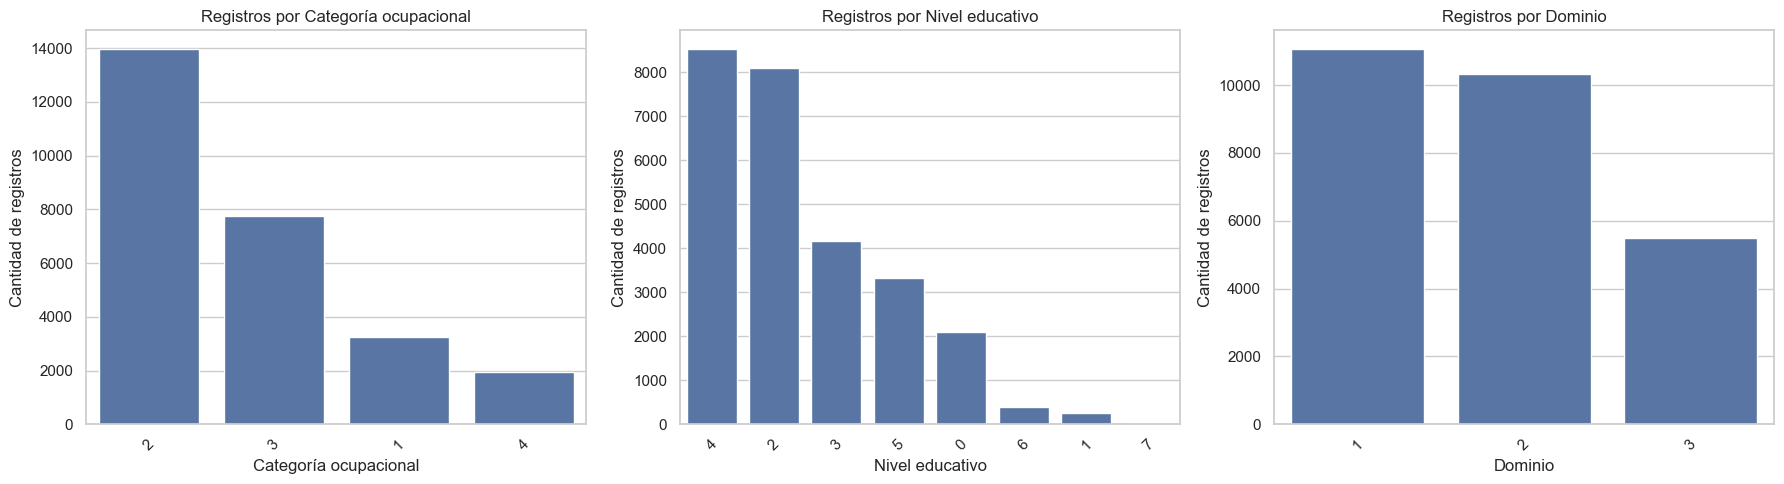

In [11]:
# --- Distribucion de registros entre categoria ocupacional, nivel educativo y dominio ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, titulo in zip(
    axes,
    ["categoria_ocupacional", "nivel_educativo", "dominio"],
    ["Categoría ocupacional", "Nivel educativo", "Dominio"],
):
    conteo = (
        df_2025_filtrado.groupBy(col).count()
        .orderBy(F.desc("count"))
        .toPandas()
    )
    sns.barplot(data=conteo, x=col, y="count", ax=ax, color="#4C72B0")
    ax.set_title(f"Registros por {titulo}")
    ax.set_xlabel(titulo)
    ax.set_ylabel("Cantidad de registros")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


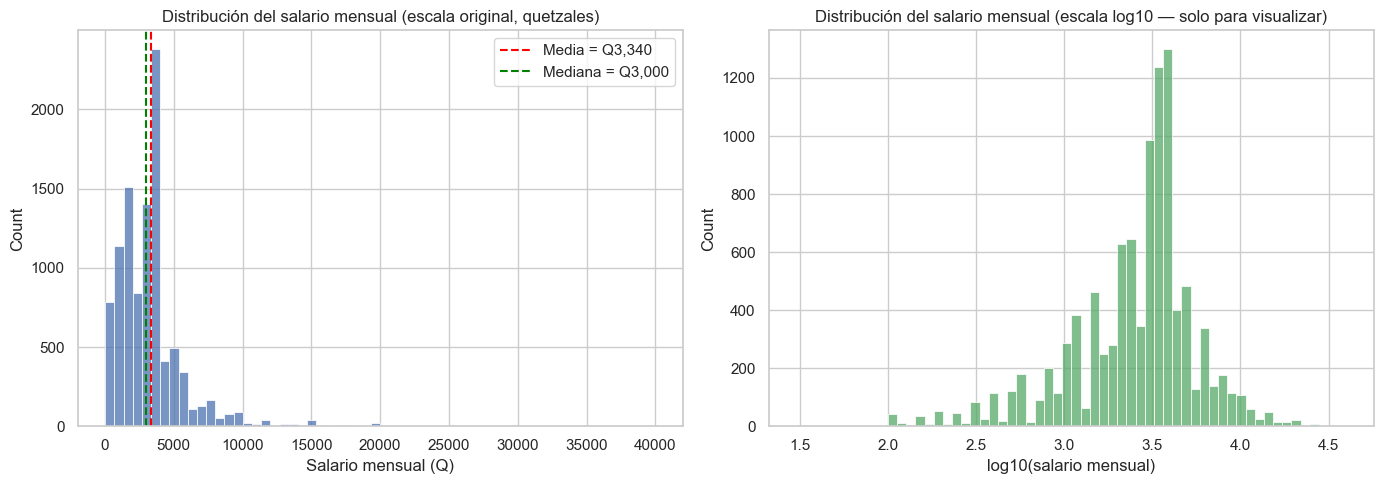

Media: Q3,340.17 | Mediana: Q3,000.00 | Diferencia (media - mediana): Q340.17


In [12]:
# --- Distribucion del salario: simetria, comparacion media vs mediana ---
muestra_salario = (
    df_2025_filtrado.select("salario_mensual")
    .sample(withReplacement=False, fraction=min(1.0, 10000 / df_2025_filtrado.count()), seed=42)
    .toPandas()
)

media_salario = tabla_descriptiva.loc[tabla_descriptiva.variable == "salario_mensual", "media"].iloc[0]
mediana_salario = tabla_descriptiva.loc[tabla_descriptiva.variable == "salario_mensual", "mediana"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(muestra_salario["salario_mensual"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].axvline(media_salario, color="red", linestyle="--", label=f"Media = Q{media_salario:,.0f}")
axes[0].axvline(mediana_salario, color="green", linestyle="--", label=f"Mediana = Q{mediana_salario:,.0f}")
axes[0].set_title("Distribución del salario mensual (escala original, quetzales)")
axes[0].set_xlabel("Salario mensual (Q)")
axes[0].legend()

sns.histplot(np.log10(muestra_salario["salario_mensual"]), bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("Distribución del salario mensual (escala log10 — solo para visualizar)")
axes[1].set_xlabel("log10(salario mensual)")

plt.tight_layout()
plt.show()

print(f"Media: Q{media_salario:,.2f} | Mediana: Q{mediana_salario:,.2f} | "
      f"Diferencia (media - mediana): Q{media_salario - mediana_salario:,.2f}")


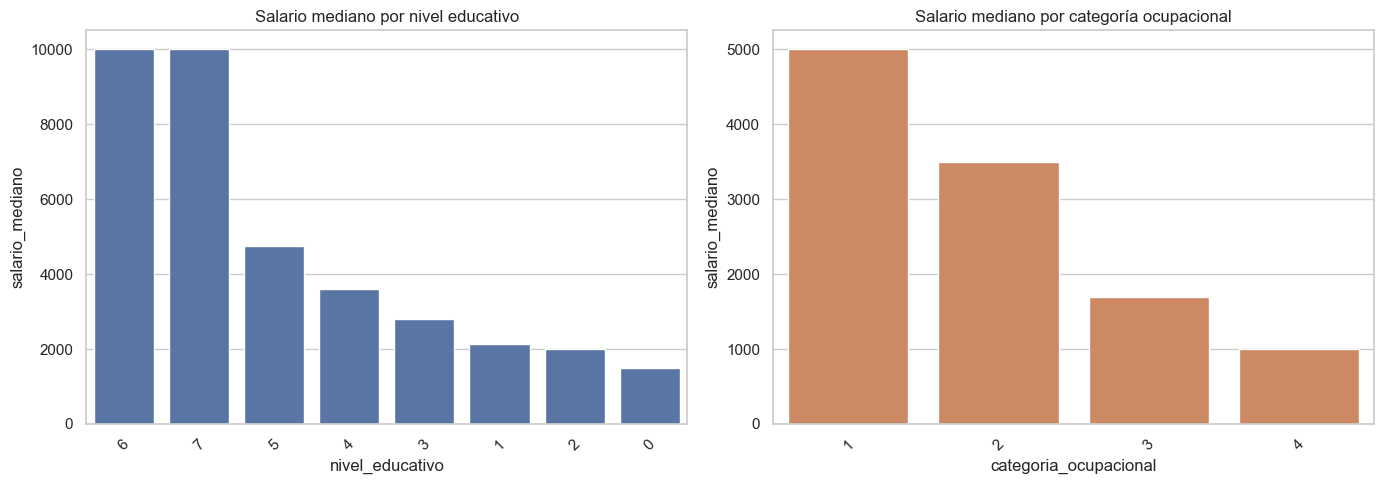

Salario mediano por nivel educativo:
nivel_educativo  salario_mediano    n
              6          10000.0  403
              7          10000.0   34
              5           4750.0 3337
              4           3600.0 8530
              3           2800.0 4159
              1           2140.0  260
              2           2000.0 8094
              0           1500.0 2094

Salario mediano por categoria ocupacional (1=gobierno, 2=empresa privada, 3=jornalero/peon, 4=servicio domestico):
categoria_ocupacional  salario_mediano     n
                    1           5000.0  3257
                    2           3500.0 13961
                    3           1700.0  7759
                    4           1000.0  1934


In [13]:
# --- Salario mediano por nivel educativo y por categoria ocupacional ---
mediana_por_grupo = lambda col: (
    df_2025_filtrado.groupBy(col)
    .agg(
        F.expr("percentile_approx(salario_mensual, 0.5, 1000)").alias("salario_mediano"),
        F.count("*").alias("n"),
    )
    .orderBy(F.desc("salario_mediano"))
    .toPandas()
)

mediana_nivel_educ = mediana_por_grupo("nivel_educativo")
mediana_categ_ocup = mediana_por_grupo("categoria_ocupacional")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=mediana_nivel_educ, x="nivel_educativo", y="salario_mediano", ax=axes[0], color="#4C72B0")
axes[0].set_title("Salario mediano por nivel educativo")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=mediana_categ_ocup, x="categoria_ocupacional", y="salario_mediano", ax=axes[1], color="#DD8452")
axes[1].set_title("Salario mediano por categoría ocupacional")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Salario mediano por nivel educativo:")
print(mediana_nivel_educ.to_string(index=False))
print()
print("Salario mediano por categoria ocupacional (1=gobierno, 2=empresa privada, 3=jornalero/peon, 4=servicio domestico):")
print(mediana_categ_ocup.to_string(index=False))


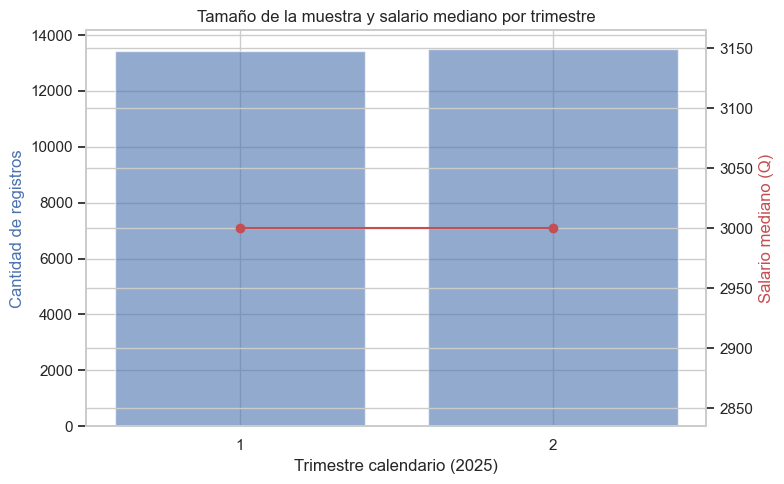

,trimestre_calendario,n_registros,salario_mediano
0,1,13419,3000.0
1,2,13492,3000.0


In [14]:
# --- Tamano de muestra y salario mediano por trimestre calendario ---
por_trimestre = (
    df_2025_filtrado.groupBy("trimestre_calendario")
    .agg(
        F.count("*").alias("n_registros"),
        F.expr("percentile_approx(salario_mensual, 0.5, 1000)").alias("salario_mediano"),
    )
    .orderBy("trimestre_calendario")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.bar(por_trimestre["trimestre_calendario"], por_trimestre["n_registros"],
        color="#4C72B0", alpha=0.6, label="N registros")
ax2.plot(por_trimestre["trimestre_calendario"], por_trimestre["salario_mediano"],
         color="#C44E52", marker="o", label="Salario mediano")

ax1.set_xlabel("Trimestre calendario (2025)")
ax1.set_ylabel("Cantidad de registros", color="#4C72B0")
ax2.set_ylabel("Salario mediano (Q)", color="#C44E52")
ax1.set_xticks(por_trimestre["trimestre_calendario"])
plt.title("Tamaño de la muestra y salario mediano por trimestre")
plt.tight_layout()
plt.show()

por_trimestre


### Discusión de los resultados

- La distribución del salario mensual es **asimétrica hacia la derecha**: la **media
  (Q3,340.17)** supera a la **mediana (Q3,000.00)** por Q340.17. Los percentiles lo confirman
  (p25 = Q1,600, p75 = Q4,000, p95 = Q8,000) y la comparación del histograma en escala
  original frente a la versión `log10` (mucho más simétrica) es la firma típica de una
  variable de ingresos con una cola larga de salarios altos (máximo observado Q99,000).
- El salario mediano **aumenta con el nivel educativo**: desde Q1,500 en el nivel 0
  ("ninguno", código 0 que sí es un salario legítimo, no un faltante) hasta Q10,000 en los
  niveles 6 y 7; niveles educativos intermedios rondan Q2,000–Q4,750 (ver tabla
  `mediana_nivel_educ`). El patrón es monótono creciente con pequeñas excepciones entre los
  códigos 1 y 2.
- También varía de forma clara **entre categorías ocupacionales** (códigos de `P05C16`):
  empleado de gobierno (1) = Q5,000 > empresa privada (2) = Q3,500 > jornalero/peón (3) =
  Q1,700 > servicio doméstico (4) = Q1,000. La categoría 2 (empresa privada) concentra la
  mayor cantidad de registros (13,961).
- Los **dominios** presentes en la muestra analítica de 2025 (T1+T2) son tres: dominio 1
  (11,062 registros), dominio 2 (10,342) y dominio 3 (5,507), que es la estructura
  representada en la gráfica de registros por dominio.
- Con los dos trimestres de 2025 disponibles, el **tamaño de muestra** (T1 = 13,419;
  T2 = 13,492) y la **mediana salarial** (Q3,000 en ambos) se mantienen muy estables; el
  patrón entre trimestres deberá verificarse de nuevo una vez se incorporen III y IV de 2025
  a `data/`.

## 3. Relaciones entre variables numéricas — 5 puntos

Usando `VectorAssembler` y `Correlation.corr()` de `pyspark.ml.stat` se calcula la
correlación de Pearson entre `salario_mensual`, `edad`, `antiguedad` y `horas_semanales`
sobre el conjunto completo de 2025 (`df_2025_filtrado`). Se presenta la matriz con
etiquetas y su mapa de calor.

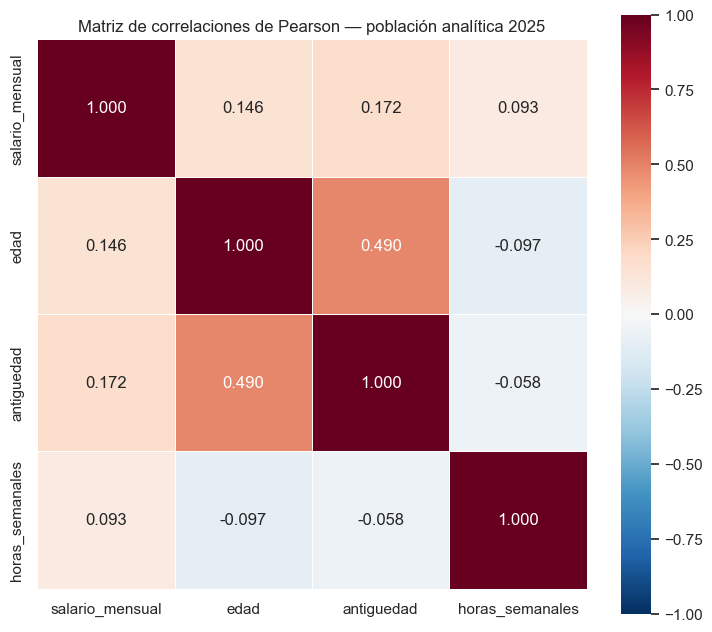

Correlaciones (absolutas) con salario_mensual:
antiguedad         0.172
edad               0.146
horas_semanales    0.093


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.146,0.172,0.093
edad,0.146,1.000,0.490,-0.097
antiguedad,0.172,0.490,1.000,-0.058
horas_semanales,0.093,-0.097,-0.058,1.000


In [15]:
# --- Matriz de correlaciones (Pearson): salario, edad, antiguedad y horas ---
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

cols_corr = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
vec_corr = "features_corr"

assembler_corr = VectorAssembler(inputCols=cols_corr, outputCol=vec_corr, handleInvalid="skip")
df_vec_corr = assembler_corr.transform(df_2025_filtrado.select(*cols_corr))

matriz_corr = Correlation.corr(df_vec_corr, vec_corr).collect()[0][0].toArray()
df_corr = pd.DataFrame(matriz_corr, index=cols_corr, columns=cols_corr).round(3)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(df_corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlaciones de Pearson — población analítica 2025")
plt.tight_layout()
plt.show()

# Asociacion lineal con el salario (ordenada de mayor a menor)
corr_salario = df_corr["salario_mensual"].drop("salario_mensual").abs().sort_values(ascending=False)
print("Correlaciones (absolutas) con salario_mensual:")
print(corr_salario.to_string())

df_corr

### Interpretación de las correlaciones

- **¿Qué variables presentan mayor asociación lineal con el salario?**
  Las tres correlaciones con `salario_mensual` son **positivas pero débiles**:
  `antiguedad` (0.172) > `edad` (0.146) > `horas_semanales` (0.093). Es decir, dentro del
  conjunto de asalariados con salario positivo, ninguna variable numérica individual explica
  por sí sola una fracción importante de la variación del salario: la relación lineal es
  modesta. Esto sugiere que una parte relevante del salario se asocia con características
  **categóricas** (nivel educativo, categoría ocupacional, dominio) que se incorporarán en los
  modelos supervisados de la segunda parte del laboratorio, más que con una sola variable
  continua.
- **¿Existe relación entre edad y antigüedad?**
  Sí, es la relación más fuerte de la matriz: **0.490**, positiva y de magnitud moderada.
  Es coherente con que a mayor edad los trabajadores acumulan más años de antigüedad en su
  ocupación; la correlación no es alta (cercana a 1) porque la antigüedad depende también de
  la historia laboral específica (entrada tardía al mercado, cambios de empleo, reincorporación)
  y no solo de la edad.
- Las relaciones de `horas_semanales` con edad (-0.097) y antigüedad (-0.058) son débiles y
  ligeramente negativas: las horas de la jornada habitual no muestran un vínculo lineal
  relevante con la edad ni con la antigüedad en este conjunto.

## 4. Segmentación de perfiles mediante KMeans
### 4.1 Selección de variables y estandarización

Se usa como base **edad, antiguedad y horas_semanales**: son las tres variables numéricas
continuas del conjunto (las dos primeras, además, están marcadas explícitamente para
clustering en la tabla de variables del enunciado). Las variables categóricas
(nivel_educativo, categoria_ocupacional, dominio) se dejan fuera del clustering en sí, pero
se usan después para **describir** cada cluster una vez formado.

`salario_mensual` se deja fuera de la segmentación principal a propósito, y se prueba por
separado más abajo: es la variable objetivo, y como ya se vio en el
Ejercicio 3 tiene una correlación débil con las otras tres variables, por lo que incluirla
tiende a producir clusters dominados por el nivel de ingreso (básicamente "salario
alto/medio/bajo") en lugar de perfiles basados en características personales y laborales,
que es lo que pide la pregunta de investigación del laboratorio.

Antes de aplicar KMeans, las variables se estandarizan (media 0, desviación 1) con
`StandardScaler`, ya que KMeans usa distancia euclidiana y, sin estandarizar, la variable
con mayor escala (horas_semanales, hasta 168) dominaría por completo el cálculo de
distancias frente a edad o antiguedad.

In [16]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

SEED = 42
cols_cluster_base = ["edad", "antiguedad", "horas_semanales"]

df_cluster_base = df_2025_filtrado.select(*cols_cluster_base, "salario_mensual",
                                           "nivel_educativo", "categoria_ocupacional", "dominio").persist()
print("Registros disponibles para clustering:", df_cluster_base.count())

assembler_base = VectorAssembler(inputCols=cols_cluster_base, outputCol="features_raw", handleInvalid="skip")
scaler_base = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

pipeline_prep_base = assembler_base
df_assembled_base = pipeline_prep_base.transform(df_cluster_base)
scaler_model_base = scaler_base.fit(df_assembled_base)
df_scaled_base = scaler_model_base.transform(df_assembled_base).persist()
df_scaled_base.count()  # materializa el cache

Registros disponibles para clustering: 26911


26911

### 4.2 Determinación del número de clusters (K = 2, 3, 4, 5)

Se prueban los cuatro valores de K pedidos y se evalúan con dos criterios complementarios:

- **WSSSE** (suma de distancias al cuadrado dentro de cada cluster): siempre baja al
  aumentar K, así que se usa de forma visual (método del codo), no como criterio único.
- **Silhouette score**: mide qué tan bien separados y compactos quedan los clusters
  (va de -1 a 1; más alto es mejor). Este es el criterio principal que el equipo usa para
  elegir el mejor K, ya que sí penaliza agregar clusters que no aportan separación real.

In [17]:
def evaluar_k(df_scaled, k_values, features_col="features", seed=SEED):
    resultados = []
    evaluator = ClusteringEvaluator(featuresCol=features_col, predictionCol="cluster",
                                     metricName="silhouette", distanceMeasure="squaredEuclidean")
    for k in k_values:
        km = KMeans(featuresCol=features_col, predictionCol="cluster", k=k, seed=seed)
        modelo = km.fit(df_scaled)
        preds = modelo.transform(df_scaled)
        wssse = modelo.summary.trainingCost
        silhouette = evaluator.evaluate(preds)
        resultados.append({"k": k, "wssse": wssse, "silhouette": silhouette})
        print(f"k={k}: WSSSE={wssse:,.1f}  |  silhouette={silhouette:.4f}")
    return pd.DataFrame(resultados)


print("=== Clustering SIN salario (edad, antiguedad, horas_semanales) ===")
tabla_k_base = evaluar_k(df_scaled_base, [2, 3, 4, 5])
tabla_k_base

=== Clustering SIN salario (edad, antiguedad, horas_semanales) ===
k=2: WSSSE=54,172.9  |  silhouette=0.5544
k=3: WSSSE=42,638.5  |  silhouette=0.4585
k=4: WSSSE=32,922.0  |  silhouette=0.4755
k=5: WSSSE=29,075.3  |  silhouette=0.4830


,k,wssse,silhouette
0,2,54172.876497,0.554370
1,3,42638.490512,0.458463
2,4,32922.040591,0.475482
3,5,29075.320826,0.483007


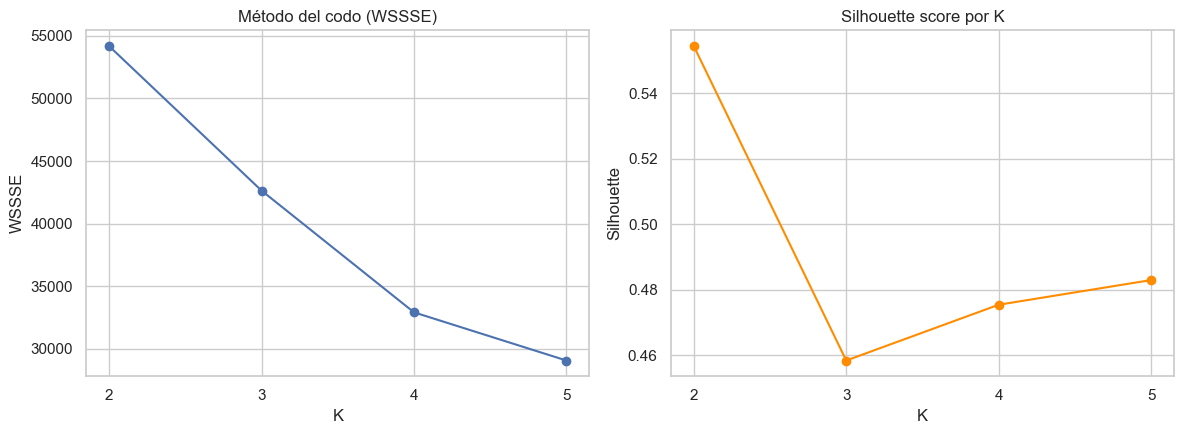

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(tabla_k_base["k"], tabla_k_base["wssse"], marker="o")
axes[0].set_title("Método del codo (WSSSE)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("WSSSE")
axes[0].set_xticks(tabla_k_base["k"])

axes[1].plot(tabla_k_base["k"], tabla_k_base["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette score por K")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
axes[1].set_xticks(tabla_k_base["k"])

plt.tight_layout()
plt.show()

### 4.3 ¿Vale la pena incluir el salario en el clustering?

Se repite exactamente el mismo procedimiento (estandarización + K=2,3,4,5) agregando
`salario_mensual` como cuarta variable, para comparar los silhouette scores contra la
versión sin salario y decidir con evidencia, no solo con la justificación teórica de 4.1.

In [19]:
cols_cluster_full = ["edad", "antiguedad", "horas_semanales", "salario_mensual"]

assembler_full = VectorAssembler(inputCols=cols_cluster_full, outputCol="features_raw_full", handleInvalid="skip")
scaler_full = StandardScaler(inputCol="features_raw_full", outputCol="features_full", withMean=True, withStd=True)

df_assembled_full = assembler_full.transform(df_cluster_base)
scaler_model_full = scaler_full.fit(df_assembled_full)
df_scaled_full = scaler_model_full.transform(df_assembled_full).persist()

print("=== Clustering CON salario (edad, antiguedad, horas_semanales, salario_mensual) ===")
tabla_k_full = evaluar_k(df_scaled_full, [2, 3, 4, 5], features_col="features_full")

comparacion_k = tabla_k_base.merge(tabla_k_full, on="k", suffixes=("_sin_salario", "_con_salario"))
comparacion_k

=== Clustering CON salario (edad, antiguedad, horas_semanales, salario_mensual) ===
k=2: WSSSE=79,938.6  |  silhouette=0.5092
k=3: WSSSE=68,007.0  |  silhouette=0.3591
k=4: WSSSE=58,236.6  |  silhouette=0.3994
k=5: WSSSE=54,498.8  |  silhouette=0.4043


,k,wssse_sin_salario,silhouette_sin_salario,wssse_con_salario,silhouette_con_salario
0,2,54172.876497,0.554370,79938.565442,0.509231
1,3,42638.490512,0.458463,68007.032327,0.359074
2,4,32922.040591,0.475482,58236.565108,0.399423
3,5,29075.320826,0.483007,54498.822678,0.404251


**¿Vale la pena incluir el salario en el clustering?**
No. Agregar salario_mensual empeora la calidad de la segmentación en los cuatro valores de
K probados: el silhouette score cae en cada caso (por ejemplo, en K=2 pasa de 0.554 sin
salario a 0.509 con salario; en K=5, de 0.483 a 0.404). Esto confirma con evidencia lo que
se anticipaba en 4.1: el salario no comparte un patrón claro con edad, antigüedad y horas
—ya se había visto en el Ejercicio 3 que sus correlaciones con esas variables son débiles—,
así que en vez de reforzar una estructura ya presente en los datos, introduce ruido que
hace más difícil separar los grupos de forma compacta. Por eso el modelo final se construye
únicamente con edad, antigüedad y horas_semanales, y el salario se deja como variable de
referencia para describir los clusters después de formados, no para construirlos.

### 4.4 Modelo final y descripción de los clusters

Se entrena el modelo final con el mejor K según silhouette (variables sin salario), y se
describe cada cluster con el promedio de las variables numéricas y la categoría más
frecuente de cada variable categórica, más el salario promedio como referencia (aunque no
se usó para formar los clusters).

In [20]:
mejor_k = int(tabla_k_base.loc[tabla_k_base["silhouette"].idxmax(), "k"])
print("Mejor K según silhouette:", mejor_k)

kmeans_final = KMeans(featuresCol="features", predictionCol="cluster", k=mejor_k, seed=SEED)
modelo_final = kmeans_final.fit(df_scaled_base)
df_con_cluster = modelo_final.transform(df_scaled_base).persist()

print("Tamaño de cada cluster:")
df_con_cluster.groupBy("cluster").count().orderBy("cluster").show()

Mejor K según silhouette: 2
Tamaño de cada cluster:
+-------+-----+
|cluster|count|
+-------+-----+
|      0|19508|
|      1| 7403|
+-------+-----+



In [21]:
from pyspark.sql import functions as F

resumen_numerico = (
    df_con_cluster.groupBy("cluster")
    .agg(
        F.count("*").alias("n"),
        F.round(F.mean("edad"), 1).alias("edad_media"),
        F.round(F.mean("antiguedad"), 1).alias("antiguedad_media"),
        F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
        F.round(F.mean("salario_mensual"), 0).alias("salario_medio"),
        F.round(F.expr("percentile_approx(salario_mensual, 0.5)"), 0).alias("salario_mediano"),
    )
    .orderBy("cluster")
    .toPandas()
)
resumen_numerico

,cluster,n,edad_media,antiguedad_media,horas_media,salario_medio,salario_mediano
0,0,19508,28.9,2.5,47.9,3105.0,3000.0
1,1,7403,51.1,14.0,41.1,3959.0,3334.0


In [22]:
def categoria_mas_frecuente(df, cluster_col, cat_col):
    w = Window.partitionBy(cluster_col).orderBy(F.desc("n"))
    return (
        df.groupBy(cluster_col, cat_col).agg(F.count("*").alias("n"))
        .withColumn("rank", F.row_number().over(w))
        .filter(F.col("rank") == 1)
        .select(cluster_col, F.col(cat_col).alias(f"{cat_col}_mas_frecuente"), "n")
        .orderBy(cluster_col)
    )

resumen_categorico = (
    categoria_mas_frecuente(df_con_cluster, "cluster", "nivel_educativo").toPandas()
    .merge(categoria_mas_frecuente(df_con_cluster, "cluster", "categoria_ocupacional").toPandas(),
           on="cluster", suffixes=("_edu", "_ocup"))
    .merge(categoria_mas_frecuente(df_con_cluster, "cluster", "dominio").toPandas()
           .rename(columns={"dominio_mas_frecuente": "dominio_mas_frecuente", "n": "n_dom"}),
           on="cluster")
)
resumen_categorico

,cluster,nivel_educativo_mas_frecuente,n_edu,categoria_ocupacional_mas_frecuente,n_ocup,dominio_mas_frecuente,n_dom
0,0,4,6870,2,10942,1,7764
1,1,2,2416,2,3019,1,3298


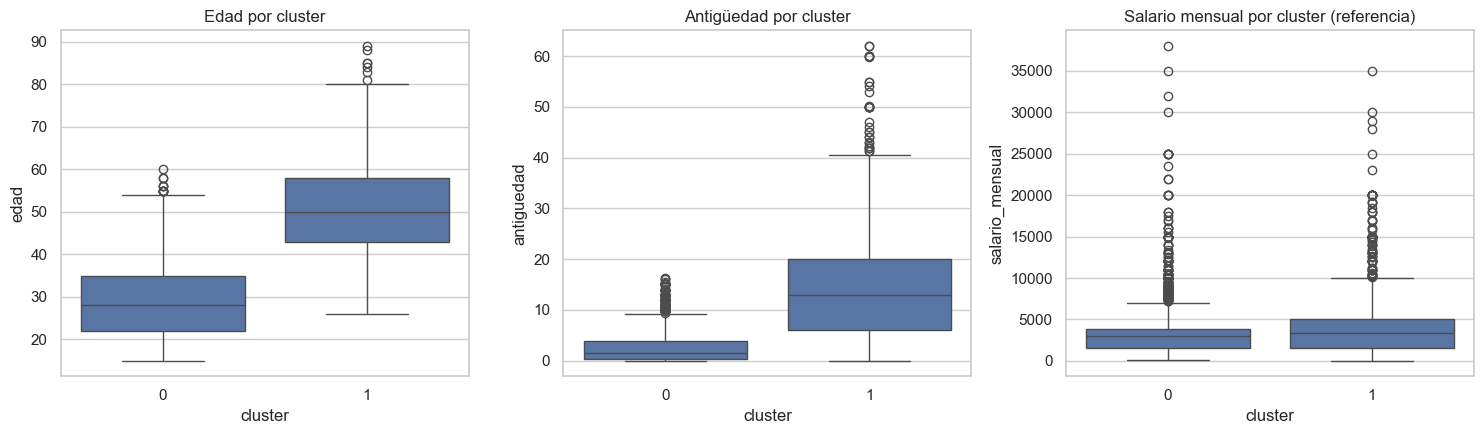

In [23]:
muestra_plot = df_con_cluster.select(
    "cluster", "edad", "antiguedad", "horas_semanales", "salario_mensual"
).sample(fraction=min(1.0, 8000 / df_con_cluster.count()), seed=SEED).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=muestra_plot, x="cluster", y="edad", ax=axes[0])
axes[0].set_title("Edad por cluster")
sns.boxplot(data=muestra_plot, x="cluster", y="antiguedad", ax=axes[1])
axes[1].set_title("Antigüedad por cluster")
sns.boxplot(data=muestra_plot, x="cluster", y="salario_mensual", ax=axes[2])
axes[2].set_title("Salario mensual por cluster (referencia)")
plt.tight_layout()
plt.show()

### 4.5 Descripción de cada cluster

Según el silhouette score, el mejor valor fue **K = 2** (0.554, el más alto de los cuatro
probados y bastante por encima de K=3, 4 o 5), lo que indica que la población analítica se
separa naturalmente en dos grandes perfiles en vez de varios grupos más finos:

- **Cluster 0 — "Trabajadores jóvenes, de entrada reciente" (19,508 personas, 73% del
  total):** edad promedio de 28.9 años y apenas 2.5 años de antigüedad en promedio, con la
  jornada más larga (47.9 horas/semana). El nivel educativo más frecuente es el más alto
  de la escala (código 4) y la categoría ocupacional predominante es empleado de empresa
  privada (código 2), sobre todo en el dominio 1. Su salario mediano de referencia es
  Q3,000.
- **Cluster 1 — "Trabajadores consolidados, de alta antigüedad" (7,403 personas, 27% del
  total):** edad promedio de 51.1 años y una antigüedad notablemente mayor (14 años en
  promedio), con una jornada algo más corta (41.1 horas/semana). Aquí el nivel educativo
  más frecuente es más bajo (código 2) que en el cluster 0, aunque la categoría ocupacional
  predominante también es empleado de empresa privada. Su salario mediano de referencia es
  más alto, Q3,334.

Vale la pena notar que, aunque el salario no se usó para formar los grupos, el cluster de
trabajadores más antiguos sí termina con un salario algo mayor, coherente con la
correlación positiva entre antigüedad y salario ya vista en el
Ejercicio 3, pero la diferencia entre ambos clusters es moderada, no drástica: el boxplot
de salario muestra bastante traslape entre los dos grupos, mientras que en edad y
antigüedad la separación es mucho más clara y con menos superposición. Esto refuerza que
la segmentación captura sobre todo una diferencia de etapa de vida laboral
(recién llegados vs. consolidados), y solo de forma secundaria una diferencia de ingreso.